# Tag & Annotation Quality
In this notebook, we compute interrater agreement and analyse the quality per tag.

### Crawling from Google Drive

In [24]:
import gspread
import os
import pandas as pd

# init google sheets client
gc = gspread.service_account(filename="../service_account.json")

# load sheet URLs from file
sheets_file = "data/tags/curation/curated/sheets.txt"
with open(sheets_file, "r") as f:
    sheet_urls = [line.strip() for line in f.readlines() if line.strip()]

curated_dir = "data/tags/curation/curated"
sh_ids = []
for sheet_url in sheet_urls:
    sh = gc.open_by_url(sheet_url)

    # iterate through all worksheets and save as CSV
    for ws in sh.worksheets():
        # make output directory
        sh_id = sh.url.split("/")[-1]
        sh_ids.append(sh_id)
        output_dir = os.path.join(curated_dir, sh_id)
        os.makedirs(output_dir, exist_ok=True)
        output_file = os.path.join(output_dir, f"{ws.title}.csv")
        
        # save each worksheet as CSV
        df = pd.DataFrame(ws.get_all_records())
        df.to_csv(output_file, index=False)
        print(f"Saved {output_file}")


Saved data/tags/curation/curated/1-Qr4CfJeRrnIuCNlGRHJX1accgKJlUgvPfrdam1xl0A/guidelines.csv
Saved data/tags/curation/curated/1-Qr4CfJeRrnIuCNlGRHJX1accgKJlUgvPfrdam1xl0A/r1_cover.csv
Saved data/tags/curation/curated/1-Qr4CfJeRrnIuCNlGRHJX1accgKJlUgvPfrdam1xl0A/r2_live.csv
Saved data/tags/curation/curated/1-Qr4CfJeRrnIuCNlGRHJX1accgKJlUgvPfrdam1xl0A/r3_guitar.csv
Saved data/tags/curation/curated/1-Qr4CfJeRrnIuCNlGRHJX1accgKJlUgvPfrdam1xl0A/r4_karaoke.csv
Saved data/tags/curation/curated/1-Qr4CfJeRrnIuCNlGRHJX1accgKJlUgvPfrdam1xl0A/r5_reaction.csv
Saved data/tags/curation/curated/1-Qr4CfJeRrnIuCNlGRHJX1accgKJlUgvPfrdam1xl0A/r6_tutorial.csv
Saved data/tags/curation/curated/1-Qr4CfJeRrnIuCNlGRHJX1accgKJlUgvPfrdam1xl0A/r7_official.csv
Saved data/tags/curation/curated/1-Qr4CfJeRrnIuCNlGRHJX1accgKJlUgvPfrdam1xl0A/r8_acoustic.csv
Saved data/tags/curation/curated/1-Qr4CfJeRrnIuCNlGRHJX1accgKJlUgvPfrdam1xl0A/r9_bass.csv
Saved data/tags/curation/curated/1-Qr4CfJeRrnIuCNlGRHJX1accgKJlUgvPfrdam1xl

### Reading the annotation files

In [41]:
dfs = []

for sh_id in set(sh_ids):
    dir_path = os.path.join(curated_dir, sh_id)
    if not os.path.isdir(dir_path):
        continue
    for fname in os.listdir(dir_path):
        if not fname.endswith(".csv"):
            continue
        if fname == "guidelines.csv":
            continue
        fpath = os.path.join(dir_path, fname)
        try:
            df_temp = pd.read_csv(fpath)
            df_temp["source_sheet"] = sh_id
            df_temp["tag"] = os.path.basename(fpath).split(".")[0].split("_")[1]
            dfs.append(df_temp)
        except Exception as e:
            print(f"Failed to read {fpath}: {e}")

if dfs:
    df = pd.concat(dfs, ignore_index=True)
else:
    df = pd.DataFrame()

df = df.dropna(subset=["tag_correct"])
print(f"Collected {len(dfs)} CSV files. Combined dataframe shape: {df.shape}")


Collected 36 CSV files. Combined dataframe shape: (1202, 18)


### Inter-Annotator Agreement
First: transform to wide format.

In [ ]:

# assume df contains: tag, clique, version, youtube_id, sh_id, tag_correct
id_cols = ["tag", "clique", "version", "youtube_id"]

# pivot: rows = items, columns = annotators
df_wide = df.pivot_table(
    index=id_cols,
    columns="source_sheet",
    values="tag_correct",
    aggfunc="first"
)

df_wide = df_wide.replace({"yes": 1, "no": 0})
df_wide = df_wide.dropna(subset=sh_ids)



Now compute metrics:

In [65]:
import numpy as np
from sklearn.metrics import cohen_kappa_score

# extract ratings per annotator
annotators = df_wide.columns.tolist()
r1 = df_wide[annotators[0]].astype(int)
r2 = df_wide[annotators[1]].astype(int)

# total pairs
n = len(r1)

# matches (same label)
matches = (r1 == r2)
n_matches = matches.sum()
rel_matches = n_matches / n

# mismatches (different labels)
n_mismatches = n - n_matches
rel_mismatches = n_mismatches / n

# general stats
print(f"Total pairs: {n}")
print(f"Matches: {n_matches} ({rel_matches:.2%})")
print(f"Mismatches: {n_mismatches} ({rel_mismatches:.2%})")

# cohen's kappa
kappa = cohen_kappa_score(r1, r2)
print("Cohen's kappa:", round(kappa, 4))


Total pairs: 269
Matches: 243 (90.33%)
Mismatches: 26 (9.67%)
Cohen's kappa: 0.6857


### Quality per Tag
We start with the agreement rows:

In [ ]:
# transformation
df_agree = df_wide.loc[df_wide[df_wide.columns[0]] == df_wide[df_wide.columns[1]]]
colA, colB = df_wide.columns[:2]
df_agree = df_wide.loc[df_wide[colA] == df_wide[colB]]
df_agree_long = df.merge(
    df_agree.reset_index()[id_cols],
    on=id_cols,
    how="inner"
)

# group by to get annotation per tag and item
df_agree_annots = df_agree_long.groupby(id_cols, as_index=False)["tag_correct"].first()

# transform to binary
df_agree_annots.tag_correct = df_agree_annots.tag_correct.replace({"yes": 1, "no": 0}).astype(int)


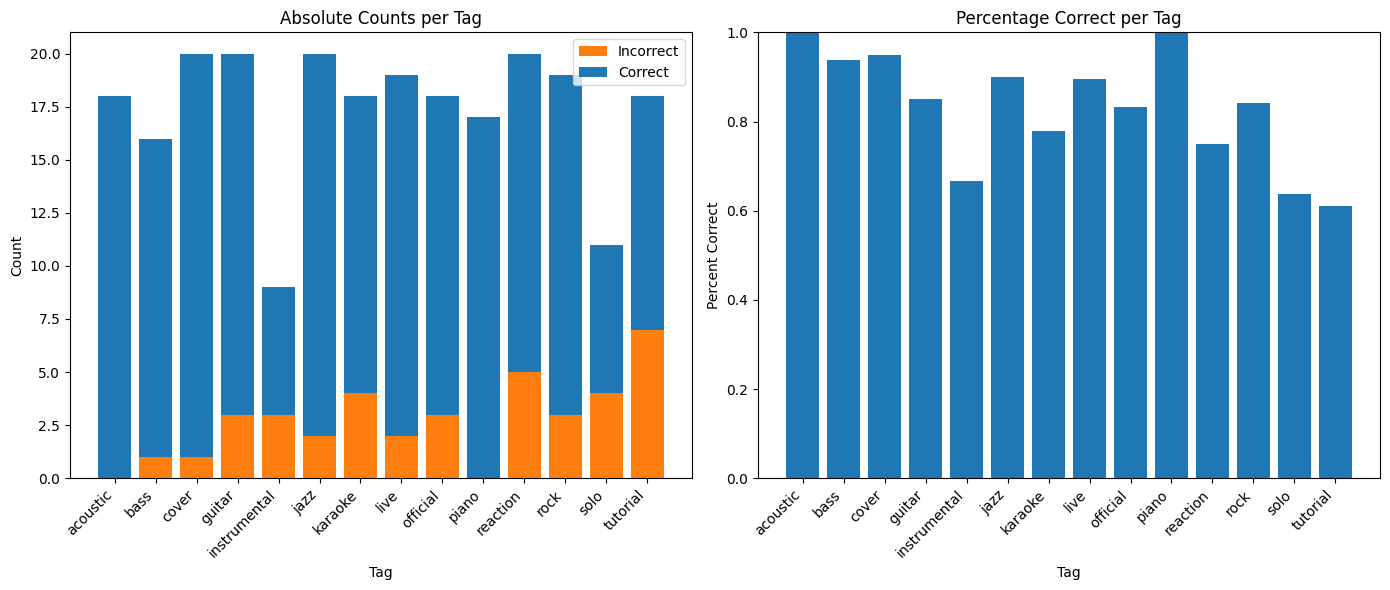

In [116]:
import matplotlib.pyplot as plt
import numpy as np

def plot_tag_correct(df, tag_col="tag", correct_col="tag_correct"):
    """
    Plot per tag the absolute counts (stacked) and percentage correct (simple bars),
    using the default color palette but consistent mapping.
    
    Args:
        df (pd.DataFrame): dataframe with at least columns `tag_col` and `correct_col`
        tag_col (str): column name identifying the tag
        correct_col (str): column name for correctness (1/0 or yes/no)
    """
    # Ensure correct_col is 0/1
    df_plot = df.copy()
    df_plot[correct_col] = df_plot[correct_col].replace({"yes":1, "no":0}).astype(int)

    # Aggregate counts
    agg_counts = (
        df_plot.groupby([tag_col, correct_col])
               .size()
               .rename("count")
               .reset_index()
    )

    # Compute percentage correct
    agg_percent = (
        df_plot.groupby(tag_col)[correct_col]
               .mean()
               .reset_index()
               .rename(columns={correct_col: "percent_correct"})
    )

    tags = agg_counts[tag_col].unique()
    x = np.arange(len(tags))

    # Get default color cycle
    prop_cycle = plt.rcParams['axes.prop_cycle']
    colors = prop_cycle.by_key()['color']
    color_map = {0: colors[1], 1: colors[0]}  # consistent: 1 = correct (blue), 0 = incorrect (orange)

    # --- Plot ---
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))

    # Absolute counts (stacked)
    counts_0 = agg_counts[agg_counts[correct_col]==0].set_index(tag_col)["count"].reindex(tags).fillna(0)
    counts_1 = agg_counts[agg_counts[correct_col]==1].set_index(tag_col)["count"].reindex(tags).fillna(0)

    axes[0].bar(x, counts_0, label="Incorrect", color=color_map[0])
    axes[0].bar(x, counts_1, bottom=counts_0, label="Correct", color=color_map[1])
    axes[0].set_title("Absolute Counts per Tag")
    axes[0].set_xlabel("Tag")
    axes[0].set_ylabel("Count")
    axes[0].set_xticks(x)
    axes[0].set_xticklabels(tags, rotation=45, ha="right")
    axes[0].legend()

    # Percentage correct (simple bars)
    axes[1].bar(x, agg_percent["percent_correct"], color=color_map[1])
    axes[1].set_title("Percentage Correct per Tag")
    axes[1].set_xlabel("Tag")
    axes[1].set_ylabel("Percent Correct")
    axes[1].set_ylim(0,1)
    axes[1].set_xticks(x)
    axes[1].set_xticklabels(tags, rotation=45, ha="right")

    plt.tight_layout()
    plt.show()

plot_tag_correct(df_agree_annots)

Now we also look at the union of agreement rows and rows only annotated by one:

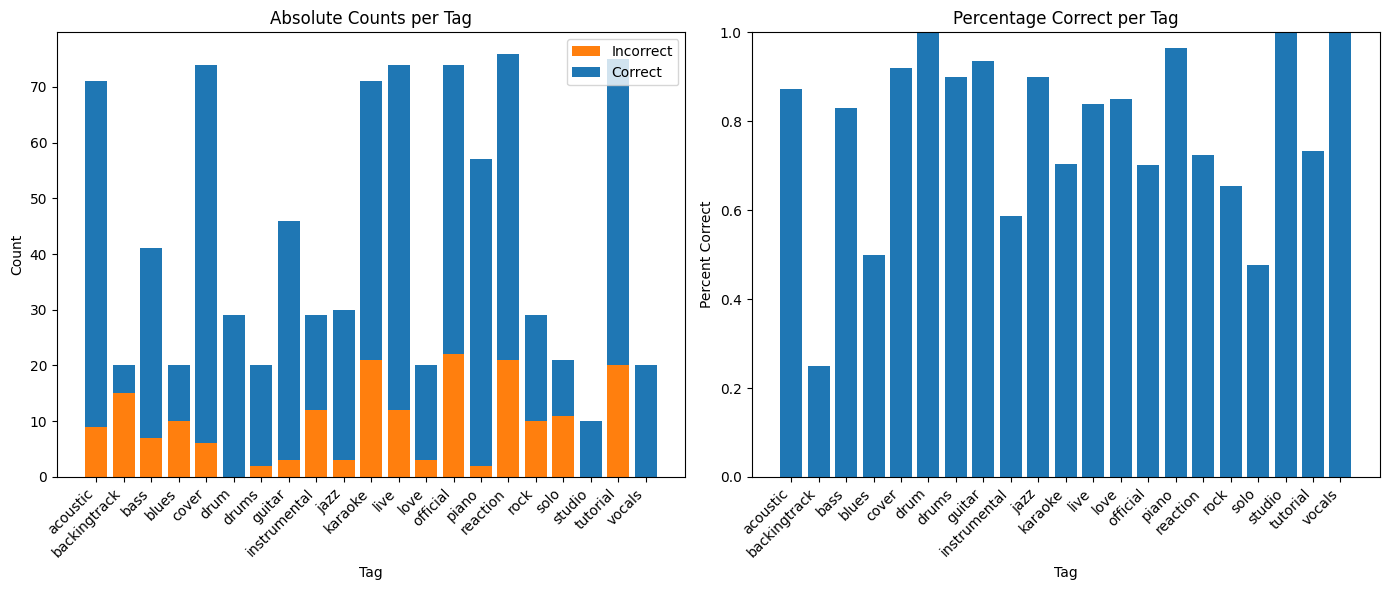

In [119]:
# transformation
counts = df.groupby(id_cols).size().rename("n_annot")
colA, colB = df_wide.columns[:2]
agree_idx = df_wide.loc[df_wide[colA] == df_wide[colB]].index
df_agree_keys = agree_idx.to_frame().reset_index(drop=True)
single_keys = counts[counts == 1].index.to_frame().reset_index(drop=True)
combined_keys = pd.concat([df_agree_keys, single_keys], ignore_index=True).drop_duplicates()
df_one_or_agreement = df.merge(combined_keys, on=id_cols, how="inner")

# group by to get annotation per tag and item
df_one_or_agree_annots = df_one_or_agreement.groupby(id_cols, as_index=False)["tag_correct"].first()

# transform to binary
df_one_or_agree_annots.tag_correct = df_one_or_agree_annots.tag_correct.replace({"yes": 1, "no": 0}).astype(int)
plot_tag_correct(df_one_or_agree_annots)
